In [2]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
# import seawater as sw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe
from tqdm import tqdm

In [3]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [4]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 12
# plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

## Importing the trends and p-values

In [5]:
path_load = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
ds        = xr.open_dataset(path_load+'ppt_evap_shf_lhf_trends_26years.nc')
lon, lat  = ds.longitude, ds.latitude
#####################################################################################
slope_decade_precipitation = ds.slope_decade_precipitation
slope_decade_evaporation   = ds.slope_decade_evaporation
slope_decade_slhf          = ds.slope_decade_slhf
slope_decade_sshf          = ds.slope_decade_sshf
#####################################################################################
p_value_precipitation = ds.p_value_precipitation
p_value_evaporation   = ds.p_value_evaporation
p_value_slhf           = ds.p_value_slhf
p_value_sshf          = ds.p_value_sshf
#####################################################################################
ds        = xr.open_dataset(path_load+'Ta_trend_26years.nc')
slope_decade_Ta, p_value_Ta = ds.slope_decade_Ta, ds.p_value_Ta
#####################################################################################
ds        = xr.open_dataset(path_load+'wind_trend_26years.nc')
slope_decade_wind, p_value_wind = ds.slope_decade_wind, ds.p_value_wind
#####################################################################################
SST_data  = xr.open_dataset(path_load+'SST_trend_26years.nc')
slope_decade_SST, p_value_SST = SST_data.slope_decade_SST.load(), SST_data.p_value_SST.load()
#####################################################################################
SLA_data = xr.open_dataset(path_load + 'SLA_trend_26years.nc')
slope_decade_SLA, p_value_SLA = SLA_data.slope_decade_SLA.load(), SLA_data.p_value_SLA.load()

## Posisitons to extract the trends

In [7]:
lat_crest_1, lon_crest_1   = -40.5, 25.3
lat_crest_2, lon_crest_2   = -40.4, 31
lat_crest_4, lon_crest_4   = -41.5, 52.3
lat_crest_7, lon_crest_7   = -44.3, 62.3
############### TROUGHS
lat_trough_1, lon_trough_1 = -38.2, 27.8
lat_trough_2, lon_trough_2 = -37.7, 32.3
lat_trough_3, lon_trough_3 = -39.5, 38
lat_trough_4, lon_trough_4 = -39.5, 50

In [11]:
precipitation_trend_C1 = slope_decade_precipitation.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
precipitation_trend_C2 = slope_decade_precipitation.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
precipitation_trend_C4 = slope_decade_precipitation.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
precipitation_trend_C7 = slope_decade_precipitation.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

precipitation_trend_T1 = slope_decade_precipitation.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
precipitation_trend_T2 = slope_decade_precipitation.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
precipitation_trend_T3 = slope_decade_precipitation.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
precipitation_trend_T4 = slope_decade_precipitation.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
evaporation_trend_C1 = slope_decade_evaporation.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
evaporation_trend_C2 = slope_decade_evaporation.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
evaporation_trend_C4 = slope_decade_evaporation.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
evaporation_trend_C7 = slope_decade_evaporation.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

evaporation_trend_T1 = slope_decade_evaporation.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
evaporation_trend_T2 = slope_decade_evaporation.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
evaporation_trend_T3 = slope_decade_evaporation.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
evaporation_trend_T4 = slope_decade_evaporation.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
slhf_trend_C1 = slope_decade_slhf.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
slhf_trend_C2 = slope_decade_slhf.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
slhf_trend_C4 = slope_decade_slhf.interp(latitude = lat_crest_4, longitude = lon_crest_4)
slhf_trend_C7 = slope_decade_slhf.interp(latitude = lat_crest_7, longitude = lon_crest_7)

slhf_trend_T1 = slope_decade_slhf.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
slhf_trend_T2 = slope_decade_slhf.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
slhf_trend_T3 = slope_decade_slhf.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
slhf_trend_T4 = slope_decade_slhf.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
sshf_trend_C1 = slope_decade_sshf.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
sshf_trend_C2 = slope_decade_sshf.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
sshf_trend_C4 = slope_decade_sshf.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
sshf_trend_C7 = slope_decade_sshf.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

sshf_trend_T1 = slope_decade_sshf.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
sshf_trend_T2 = slope_decade_sshf.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
sshf_trend_T3 = slope_decade_sshf.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
sshf_trend_T4 = slope_decade_sshf.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
wind_trend_C1 = slope_decade_wind.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
wind_trend_C2 = slope_decade_wind.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
wind_trend_C4 = slope_decade_wind.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
wind_trend_C7 = slope_decade_wind.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

wind_trend_T1 = slope_decade_wind.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
wind_trend_T2 = slope_decade_wind.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
wind_trend_T3 = slope_decade_wind.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
wind_trend_T4 = slope_decade_wind.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
Ta_trend_C1 = slope_decade_Ta.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
Ta_trend_C2 = slope_decade_Ta.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
Ta_trend_C4 = slope_decade_Ta.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
Ta_trend_C7 = slope_decade_Ta.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

Ta_trend_T1 = slope_decade_Ta.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
Ta_trend_T2 = slope_decade_Ta.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
Ta_trend_T3 = slope_decade_Ta.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
Ta_trend_T4 = slope_decade_Ta.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
SST_trend_C1 = slope_decade_SST.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
SST_trend_C2 = slope_decade_SST.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
SST_trend_C4 = slope_decade_SST.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
SST_trend_C7 = slope_decade_SST.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

SST_trend_T1 = slope_decade_SST.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
SST_trend_T2 = slope_decade_SST.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
SST_trend_T3 = slope_decade_SST.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
SST_trend_T4 = slope_decade_SST.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
SLA_trend_C1 = slope_decade_SLA.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
SLA_trend_C2 = slope_decade_SLA.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
SLA_trend_C4 = slope_decade_SLA.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
SLA_trend_C7 = slope_decade_SLA.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

SLA_trend_T1 = slope_decade_SLA.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
SLA_trend_T2 = slope_decade_SLA.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
SLA_trend_T3 = slope_decade_SLA.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
SLA_trend_T4 = slope_decade_SLA.interp(latitude = lat_trough_4, longitude = lon_trough_4).data

In [9]:
precipitation_p_value_C1 = p_value_precipitation.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
precipitation_p_value_C2 = p_value_precipitation.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
precipitation_p_value_C4 = p_value_precipitation.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
precipitation_p_value_C7 = p_value_precipitation.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

precipitation_p_value_T1 = p_value_precipitation.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
precipitation_p_value_T2 = p_value_precipitation.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
precipitation_p_value_T3 = p_value_precipitation.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
precipitation_p_value_T4 = p_value_precipitation.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
evaporation_p_value_C1 = p_value_evaporation.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
evaporation_p_value_C2 = p_value_evaporation.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
evaporation_p_value_C4 = p_value_evaporation.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
evaporation_p_value_C7 = p_value_evaporation.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

evaporation_p_value_T1 = p_value_evaporation.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
evaporation_p_value_T2 = p_value_evaporation.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
evaporation_p_value_T3 = p_value_evaporation.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
evaporation_p_value_T4 = p_value_evaporation.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
slhf_p_value_C1 = p_value_slhf.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
slhf_p_value_C2 = p_value_slhf.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
slhf_p_value_C4 = p_value_slhf.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
slhf_p_value_C7 = p_value_slhf.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

slhf_p_value_T1 = p_value_slhf.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
slhf_p_value_T2 = p_value_slhf.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
slhf_p_value_T3 = p_value_slhf.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
slhf_p_value_T4 = p_value_slhf.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
sshf_p_value_C1 = p_value_sshf.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
sshf_p_value_C2 = p_value_sshf.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
sshf_p_value_C4 = p_value_sshf.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
sshf_p_value_C7 = p_value_sshf.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

sshf_p_value_T1 = p_value_sshf.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
sshf_p_value_T2 = p_value_sshf.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
sshf_p_value_T3 = p_value_sshf.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
sshf_p_value_T4 = p_value_sshf.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
wind_p_value_C1 = p_value_wind.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
wind_p_value_C2 = p_value_wind.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
wind_p_value_C4 = p_value_wind.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
wind_p_value_C7 = p_value_wind.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

wind_p_value_T1 = p_value_wind.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
wind_p_value_T2 = p_value_wind.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
wind_p_value_T3 = p_value_wind.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
wind_p_value_T4 = p_value_wind.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
Ta_p_value_C1 = p_value_Ta.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
Ta_p_value_C2 = p_value_Ta.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
Ta_p_value_C4 = p_value_Ta.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
Ta_p_value_C7 = p_value_Ta.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

Ta_p_value_T1 = p_value_Ta.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
Ta_p_value_T2 = p_value_Ta.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
Ta_p_value_T3 = p_value_Ta.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
Ta_p_value_T4 = p_value_Ta.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
SST_p_value_C1 = p_value_SST.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
SST_p_value_C2 = p_value_SST.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
SST_p_value_C4 = p_value_SST.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
SST_p_value_C7 = p_value_SST.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

SST_p_value_T1 = p_value_SST.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
SST_p_value_T2 = p_value_SST.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
SST_p_value_T3 = p_value_SST.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
SST_p_value_T4 = p_value_SST.interp(latitude = lat_trough_4, longitude = lon_trough_4).data
###########################################################################################################
SLA_p_value_C1 = p_value_SLA.interp(latitude = lat_crest_1, longitude = lon_crest_1).data
SLA_p_value_C2 = p_value_SLA.interp(latitude = lat_crest_2, longitude = lon_crest_2).data
SLA_p_value_C4 = p_value_SLA.interp(latitude = lat_crest_4, longitude = lon_crest_4).data
SLA_p_value_C7 = p_value_SLA.interp(latitude = lat_crest_7, longitude = lon_crest_7).data

SLA_p_value_T1 = p_value_SLA.interp(latitude = lat_trough_1, longitude = lon_trough_1).data
SLA_p_value_T2 = p_value_SLA.interp(latitude = lat_trough_2, longitude = lon_trough_2).data
SLA_p_value_T3 = p_value_SLA.interp(latitude = lat_trough_3, longitude = lon_trough_3).data
SLA_p_value_T4 = p_value_SLA.interp(latitude = lat_trough_4, longitude = lon_trough_4).data

## Let's make the table

In [8]:
# cell_trend = np.array([[SLA_trend_C1, SLA_trend_C2, SLA_trend_C4, SLA_trend_C7, SLA_trend_T1, SLA_trend_T2, SLA_trend_T3],
#                        [SST_trend_C1, SST_trend_C2, SST_trend_C4, SST_trend_C7, SST_trend_T1, SST_trend_T2, SST_trend_T3],
#                        [Ta_trend_C1, Ta_trend_C2, Ta_trend_C4, Ta_trend_C7, Ta_trend_T1, Ta_trend_T2, Ta_trend_T3],
#                        [wind_trend_C1, wind_trend_C2, wind_trend_C4, wind_trend_C7, wind_trend_T1, wind_trend_T2, wind_trend_T3],
#                        [precipitation_trend_C1, precipitation_trend_C2, precipitation_trend_C4, precipitation_trend_C7, precipitation_trend_T1, precipitation_trend_T2, precipitation_trend_T3],
#                        [sshf_trend_C1, sshf_trend_C2, sshf_trend_C4, sshf_trend_C7, sshf_trend_T1, sshf_trend_T2, sshf_trend_T3],
#                        [evaporation_trend_C1, evaporation_trend_C2, evaporation_trend_C4, evaporation_trend_C7, evaporation_trend_T1, evaporation_trend_T2, evaporation_trend_T3],
#                        [slhf_trend_C1, slhf_trend_C2, slhf_trend_C4, slhf_trend_C7, slhf_trend_T1, slhf_trend_T2, slhf_trend_T3] 
#                       ])

In [12]:
cell_trend = np.array([[SLA_trend_C1, SLA_trend_C2, SLA_trend_C4, SLA_trend_T1, SLA_trend_T2, SLA_trend_T3, SLA_trend_T4],
                       [SST_trend_C1, SST_trend_C2, SST_trend_C4, SST_trend_T1, SST_trend_T2, SST_trend_T3, SST_trend_T4],
                       [Ta_trend_C1, Ta_trend_C2, Ta_trend_C4, Ta_trend_T1, Ta_trend_T2, Ta_trend_T3, Ta_trend_T4],
                       [wind_trend_C1, wind_trend_C2, wind_trend_C4, wind_trend_T1, wind_trend_T2, wind_trend_T3, wind_trend_T4],
                       [precipitation_trend_C1, precipitation_trend_C2, precipitation_trend_C4, precipitation_trend_T1, precipitation_trend_T2, precipitation_trend_T3, precipitation_trend_T4],
                       [sshf_trend_C1, sshf_trend_C2, sshf_trend_C4, sshf_trend_T1, sshf_trend_T2, sshf_trend_T3, sshf_trend_T4],
                       [evaporation_trend_C1, evaporation_trend_C2, evaporation_trend_C4, evaporation_trend_T1, evaporation_trend_T2, evaporation_trend_T3, evaporation_trend_T4],
                       [slhf_trend_C1, slhf_trend_C2, slhf_trend_C4, slhf_trend_T1, slhf_trend_T2, slhf_trend_T3, slhf_trend_T4] 
                      ])

In [9]:
# cell_p_value = np.array([[SLA_p_value_C1, SLA_p_value_C2, SLA_p_value_C4, SLA_p_value_C7, SLA_p_value_T1, SLA_p_value_T2, SLA_p_value_T3],
#                          [SST_p_value_C1, SST_p_value_C2, SST_p_value_C4, SST_p_value_C7, SST_p_value_T1, SST_p_value_T2, SST_p_value_T3],
#                          [Ta_p_value_C1, Ta_p_value_C2, Ta_p_value_C4, Ta_p_value_C7, Ta_p_value_T1, Ta_p_value_T2, Ta_p_value_T3],
#                          [wind_p_value_C1, wind_p_value_C2, wind_p_value_C4, wind_p_value_C7, wind_p_value_T1, wind_p_value_T2, wind_p_value_T3],
#                          [precipitation_p_value_C1, precipitation_p_value_C2, precipitation_p_value_C4, precipitation_p_value_C7, precipitation_p_value_T1, precipitation_p_value_T2, precipitation_p_value_T3],
#                          [sshf_p_value_C1, sshf_p_value_C2, sshf_p_value_C4, sshf_p_value_C7, sshf_p_value_T1, sshf_p_value_T2, sshf_p_value_T3],
#                          [evaporation_p_value_C1, evaporation_p_value_C2, evaporation_p_value_C4, evaporation_p_value_C7, evaporation_p_value_T1, evaporation_p_value_T2, evaporation_p_value_T3],
#                          [slhf_p_value_C1, slhf_p_value_C2, slhf_p_value_C4, slhf_p_value_C7, slhf_p_value_T1, slhf_p_value_T2, slhf_p_value_T3] 
#                         ])

In [13]:
cell_p_value = np.array([[SLA_p_value_C1, SLA_p_value_C2, SLA_p_value_C4, SLA_p_value_T1, SLA_p_value_T2, SLA_p_value_T3, SLA_p_value_T4],
                         [SST_p_value_C1, SST_p_value_C2, SST_p_value_C4, SST_p_value_T1, SST_p_value_T2, SST_p_value_T3, SST_p_value_T4],
                         [Ta_p_value_C1, Ta_p_value_C2, Ta_p_value_C4, Ta_p_value_T1, Ta_p_value_T2, Ta_p_value_T3, Ta_p_value_T4],
                         [wind_p_value_C1, wind_p_value_C2, wind_p_value_C4, wind_p_value_T1, wind_p_value_T2, wind_p_value_T3, wind_p_value_T4],
                         [precipitation_p_value_C1, precipitation_p_value_C2, precipitation_p_value_C4, precipitation_p_value_T1, precipitation_p_value_T2, precipitation_p_value_T3, precipitation_p_value_T4],
                         [sshf_p_value_C1, sshf_p_value_C2, sshf_p_value_C4, sshf_p_value_T1, sshf_p_value_T2, sshf_p_value_T3, sshf_p_value_T4],
                         [evaporation_p_value_C1, evaporation_p_value_C2, evaporation_p_value_C4, evaporation_p_value_T1, evaporation_p_value_T2, evaporation_p_value_T3, evaporation_p_value_T4],
                         [slhf_p_value_C1, slhf_p_value_C2, slhf_p_value_C4, slhf_p_value_T1, slhf_p_value_T2, slhf_p_value_T3, slhf_p_value_T4] 
                        ])

In [14]:
# rows = ['SLA', 'SST', 'Ta', 'Wind speed', 'Precipitation', 'Sensible', 'Evaporation', 'Latent']
# columns = ['C1', 'C2', 'C5', 'C7', 'T1','T2', 'T3']
# rcolors = plt.cm.BuPu(np.full(len(rows), 0.1))
# ccolors = plt.cm.BuPu(np.full(len(columns), 0.1))
# path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'

In [15]:
rows = ['SLA', 'SST', 'Ta', 'Wind speed', 'Precipitation', 'Sensible', 'Evaporation', 'Latent']
columns = ['C1', 'C2', 'C5', 'T1','T2', 'T3', 'T4']
rcolors = plt.cm.BuPu(np.full(len(rows), 0.1))
ccolors = plt.cm.BuPu(np.full(len(columns), 0.1))
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'

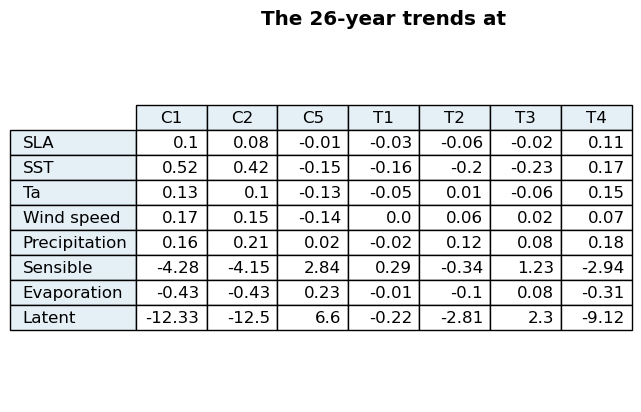

In [16]:
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.box(on=None)

the_table = plt.table(cellText=np.round(cell_trend,2), 
                      rowLabels=rows,
                      loc = 'center', colLabels=columns,
                      rowColours=rcolors, rowLoc='left', colColours=ccolors,         
         )
the_table.scale(1, 1.5)


plt.title('The 26-year trends at')
plt.savefig(path_fig + 'Tab1_trends.jpg', dpi =300, bbox_inches = 'tight')

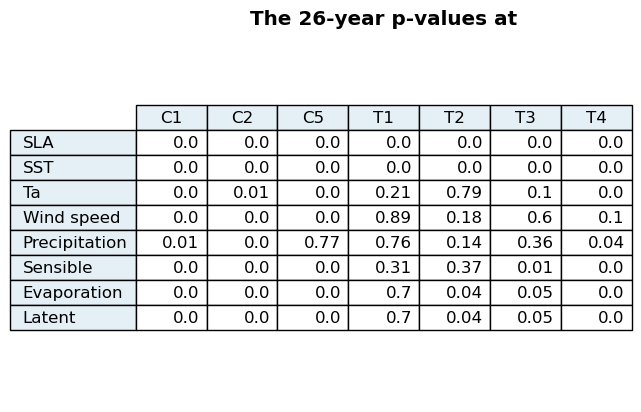

In [17]:
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.box(on=None)

the_table = plt.table(cellText=np.round(cell_p_value,2), 
                      rowLabels=rows,
                      loc = 'center', colLabels=columns,
                      rowColours=rcolors, rowLoc='left', colColours=ccolors,         
         )
the_table.scale(1, 1.5)


plt.title('The 26-year p-values at')
plt.savefig(path_fig + 'Tab1_p-values.jpg', dpi =300, bbox_inches = 'tight')

## Previous trends with C7

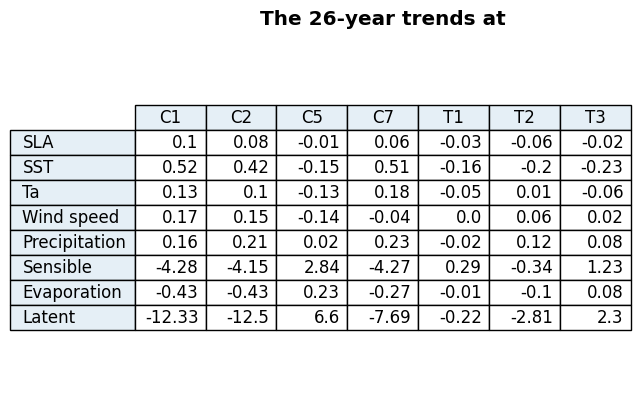

In [11]:
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.box(on=None)

the_table = plt.table(cellText=np.round(cell_trend,2), 
                      rowLabels=rows,
                      loc = 'center', colLabels=columns,
                      rowColours=rcolors, rowLoc='left', colColours=ccolors,         
         )
the_table.scale(1, 1.5)


plt.title('The 26-year trends at')
plt.savefig(path_fig + 'Tab1_trends.jpg', dpi =300, bbox_inches = 'tight')

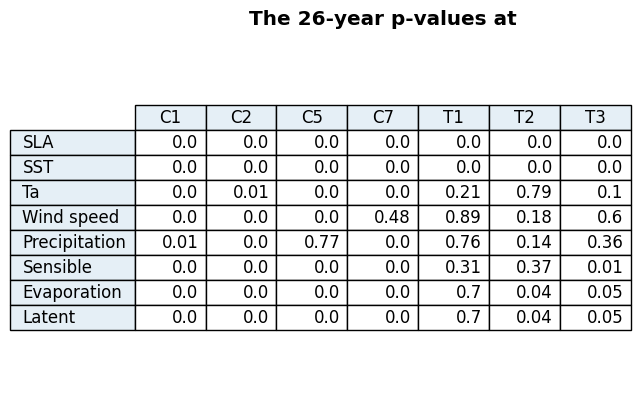

In [12]:
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.box(on=None)

the_table = plt.table(cellText=np.round(cell_p_value,2), 
                      rowLabels=rows,
                      loc = 'center', colLabels=columns,
                      rowColours=rcolors, rowLoc='left', colColours=ccolors,         
         )
the_table.scale(1, 1.5)


plt.title('The 26-year p-values at')
plt.savefig(path_fig + 'Tab1_p-values.jpg', dpi =300, bbox_inches = 'tight')